# SAGE baseline experiments - overview

Everything the co-author guide asked for, in one place: what the baselines
score, how they compare to SAGE's locked 78.4%, and which conclusions survive
a leakage-controlled split.

**Read this first, then the per-task notebooks:**

| Notebook | Guide task |
|---|---|
| `01_task1_same_feature_baselines.ipynb` | Task 1 - k-NN / SVM on the same 13 features |
| `02_task2_pointnet_raw_points.ipynb` | Task 2 - PointNet on raw point clouds |
| `03_task3_sample_efficiency.ipynb` | Task 3 - accuracy vs examples per category |
| `04_task4_robustness.ipynb` | Task 4 - downsampling and sensor noise |
| `05_task5_statistics.ipynb` | Task 5 - confidence intervals and significance |

Nothing here retrains anything. Every number is read from the CSVs that
`run_all.py` produced, so a figure in a notebook can never disagree with the
script that generated it.

In [1]:
import sys
from pathlib import Path

# Use the project's src/ modules rather than re-implementing anything here.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import results_io as rio
import viz_style as vs

vs.apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print("Reading results from:", rio.RESULTS_DIR)


Reading results from: C:\Users\suraj\Desktop\ICRA\sage_baseline_experiments\results


## The one caveat that changes how you read every number

`export_baseline_data.py` iterates over YCB-Video **frames** and emits one row
per object *per frame*. The 1109 rows are therefore repeated observations of a
much smaller set of physical objects, seen across the frames of ~12 validation
videos.

A plain `StratifiedKFold` splits those rows independently, so near-identical
views of one object land in **both** the training and the test fold, and a
classifier can retrieve a memorised neighbour instead of generalising. SAGE's
own 78.4% used a *video-level* split, so a random-split baseline is not
comparable to it.

Every task therefore reports two regimes - `random` (leaky, kept for
comparison) and `grouped` (object-aware). **Quote the grouped numbers.**

In [2]:
# How many physical objects are actually in the 1109 rows?
from data_utils import load_pointcloud_data, compute_object_groups

clouds, labels = load_pointcloud_data()
groups = compute_object_groups(clouds, distance_threshold=0.003)

object_counts = (
    pd.DataFrame({"label": labels, "group": groups})
    .groupby("label")
    .agg(distinct_objects=("group", "nunique"), rows=("group", "size"))
    .reindex(rio.CLASSES)
)

object_counts.loc["TOTAL"] = [len(np.unique(groups)), len(labels)]
object_counts

,distinct_objects,rows
label,,
box,93,475
can,55,355
mug,22,89
bottle,58,146
bowl,26,44
TOTAL,201,1109


201 distinct objects behind 1109 rows. Bowl is the extreme case: 44 rows, but
only 26 genuinely different bowls.

## Headline comparison

In [3]:
summary = rio.load_summary()

headline = summary[summary["split"].isin(["video_level", "grouped"])].copy()
headline["model"] = headline["model"].map(rio.pretty)

rio.as_percent(headline)[
    ["model", "split", "overall_accuracy", "balanced_accuracy"]
    + rio.CLASS_ACCURACY_COLUMNS
].reset_index(drop=True)

,model,split,overall_accuracy,balanced_accuracy,box_accuracy,can_accuracy,mug_accuracy,bottle_accuracy,bowl_accuracy
0,SAGE,video_level,78.4,NaN,94.7,94.9,32.6,31.5,18.2
1,k-NN,grouped,90.0,79.4,93.3,98.9,65.2,82.9,56.8
2,SVM (linear),grouped,84.1,60.6,97.7,99.2,30.3,55.5,20.5
3,SVM (RBF),grouped,85.3,64.8,96.4,98.9,36.0,63.0,29.5
4,PointNet,grouped,93.9,92.8,93.1,97.5,94.4,88.4,90.9


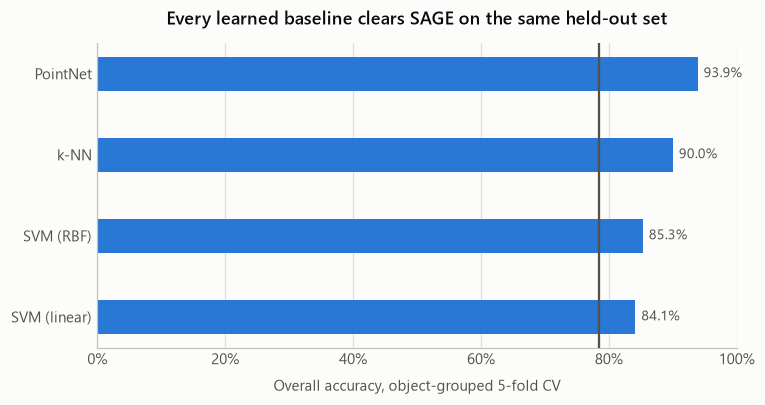

In [4]:
# Overall accuracy, grouped split, against the SAGE reference line.
# One series -> one colour; SAGE is a reference rule, not a bar.
plot_df = (
    summary[summary["split"] == "grouped"]
    .assign(name=lambda d: d["model"].map(rio.pretty))
    .sort_values("overall_accuracy")
)

fig, ax = plt.subplots(figsize=(7.5, 3.6))

bars = ax.barh(
    plot_df["name"],
    plot_df["overall_accuracy"] * 100,
    height=0.42,
    color=vs.BLUE,
)

vs.label_bars(ax, bars, plot_df["overall_accuracy"] * 100, fmt="{:.1f}%")

ax.axvline(78.4, color=vs.SAGE_COLOR, linewidth=1.5, zorder=3)
ax.annotate(
    "SAGE 78.4%",
    xy=(78.4, -0.75),
    xytext=(5, 0),
    textcoords="offset points",
    va="center", ha="left", fontsize=9, color=vs.SAGE_COLOR,
)

vs.percent_axis(ax, "x")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel("Overall accuracy, object-grouped 5-fold CV")
ax.set_title("Every learned baseline clears SAGE on the same held-out set")
plt.show()

### What the leakage was worth

Before/after per model, random split to object-grouped split. The connector
length *is* the inflation.

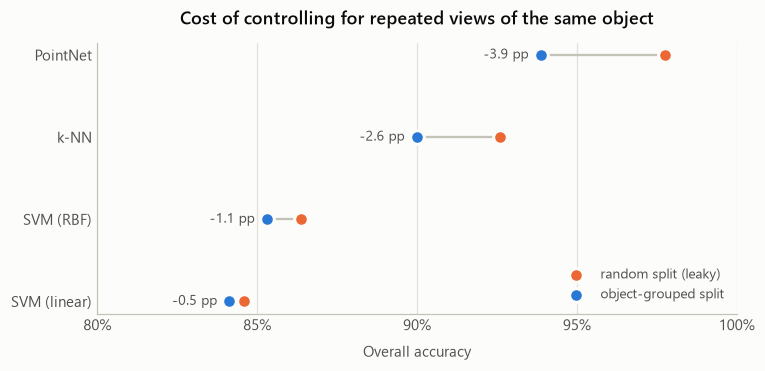

split,model,random,grouped,delta
0,PointNet,0.977457,0.938683,-3.877367
1,k-NN,0.926060,0.899910,-2.614968
2,SVM (RBF),0.863841,0.853021,-1.082056
3,SVM (linear),0.845807,0.841298,-0.450857


In [5]:
paired = (
    summary[summary["split"] != "video_level"]
    .pivot(index="base_model", columns="split", values="overall_accuracy")
    .dropna()
)
paired["delta"] = (paired["grouped"] - paired["random"]) * 100
paired = paired.sort_values("delta")

fig, ax = plt.subplots(figsize=(7.5, 3.2))

vs.dumbbell(
    ax,
    [rio.pretty(m) for m in paired.index],
    paired["random"] * 100,
    paired["grouped"] * 100,
    start_color=vs.ORANGE,
    end_color=vs.BLUE,
    start_label="random split (leaky)",
    end_label="object-grouped split",
)

for position, (_, row) in enumerate(paired.iterrows()):
    ax.annotate(
        f"{row['delta']:+.1f} pp",
        xy=(min(row["random"], row["grouped"]) * 100, position),
        xytext=(-8, 0), textcoords="offset points",
        va="center", ha="right", fontsize=9, color=vs.INK_SECONDARY,
    )

vs.percent_axis(ax, "x", lo=80, top=100, step=5)
ax.set_xlabel("Overall accuracy")
ax.set_title("Cost of controlling for repeated views of the same object")
ax.legend(loc="lower right")
plt.show()

rio.as_percent(paired.reset_index().assign(
    model=lambda d: d["base_model"].map(rio.pretty)
))[["model", "random", "grouped", "delta"]]

k-NN and PointNet - the two models most able to memorise - lose the most. The
SVMs barely move. That ordering is the signature of leakage rather than of a
general difficulty change.

## The four findings

1. **The 13D feature set, not the scoring formula, is the ceiling on mug and
   bowl.** A linear SVM trained on the *identical* features reproduces SAGE's
   per-class failure profile (r = 0.96): mug 30.3% vs SAGE's 32.6%, bowl 20.5%
   vs 18.2%. Where SAGE fails, a learned classifier on the same numbers fails
   the same way. -> notebook 01

2. **Bottle is the exception, and it is a scoring problem.** Same inputs, but
   55.5% against SAGE's 31.5%. That one is recoverable without changing the
   representation. -> notebook 01

3. **Raw points carry far more than the 13D projection keeps.** PointNet
   reaches 93.9% overall / 92.8% balanced on the grouped split, against 64.8%
   balanced for the best feature baseline. -> notebook 02

4. **SAGE's can-vs-bottle gap is real**, not small-sample noise: +63.4 pp
   [+55.3, +71.1], Fisher exact p = 7.6e-50. -> notebook 05

## A second comparability caveat

Even with leakage controlled, the two are not measured the same way. The
baselines cross-validate *within* the validation set; SAGE's registry was built
on the training videos and evaluated zero-shot on this one. Part of the
baseline margin is that distributional advantage rather than a representational
one, so the grouped numbers are an **upper bound** on the learned classifiers,
not a clean like-for-like estimate.

The clean fix is a re-export carrying `video_id` / `frame_key` per instance.